#Install & Import Libraries

In [ ]:
!pip install pyspark -q
!pip install folium branca -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression, DecisionTreeClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    RegressionEvaluator, MulticlassClassificationEvaluator, BinaryClassificationEvaluator
)
from pyspark.ml import Pipeline

import folium
from folium.plugins import MarkerCluster
import json

# ─── Plot Style ───────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PALETTE = {
    'BNP':    '#1f77b4',
    'Jamaat': '#2ca02c',
    'NCP':    '#ff7f0e',
    'IND':    '#9467bd',
    'Other':  '#8c564b',
}
BD_DIVISIONS = {
    'Rangpur':    (25.745,  89.275),
    'Rajshahi':   (24.367,  88.600),
    'Khulna':     (22.845,  89.568),
    'Barishal':   (22.700,  90.370),
    'Mymensingh': (24.750,  90.407),
    'Dhaka':      (23.810,  90.407),
    'Sylhet':     (24.900,  91.872),
    'Chittagong': (22.356,  91.784),
}

print(" Libraries loaded successfully.")

 Libraries loaded successfully.


#  Upload Data Files

In [ ]:
from google.colab import files

print("Upload election.csv ...")
uploaded = files.upload()
print("Upload gonovote.csv ...")
uploaded2 = files.upload()

print("Files uploaded.")

Upload election.csv ...


Saving election.csv to election.csv
Upload gonovote.csv ...


Saving gonovote.csv to gonovote.csv
Files uploaded.


# Load & Clean Election Data


In [ ]:

raw = pd.read_csv('election.csv', header=None)

# Row 1 is the true header
raw.columns = raw.iloc[1]
raw = raw.iloc[2:].reset_index(drop=True)

raw.columns = [
    'Constituency_No', 'Division', 'Constituency_Name',
    'Poverty_Rate', 'Literacy_Rate',
    'Winner_Candidate', 'Winner_Party', 'Winner_Votes',
    'Runner_Candidate', 'Runner_Party', 'Runner_Votes',
    'Margin', 'Total_Voters', 'Male_Voters',
    'Female_Voters', 'Transgender_Voters'
]

# Drop election-postponed rows
df = raw[raw['Winner_Party'].notna() &
         (raw['Winner_Candidate'] != 'Election postponed')].copy()

# Numeric conversion helper
def to_num(col):
    return pd.to_numeric(
        col.astype(str).str.replace(',', '').str.strip(),
        errors='coerce'
    )

for c in ['Constituency_No','Poverty_Rate','Literacy_Rate',
          'Winner_Votes','Runner_Votes','Margin',
          'Total_Voters','Male_Voters','Female_Voters','Transgender_Voters']:
    df[c] = to_num(df[c])

df['Division'] = df['Division'].str.strip()

# ── Derived Features ──────────────────────────
df['Total_Cast_Votes'] = df['Winner_Votes'] + df['Runner_Votes']
df['Voter_Turnout_Pct'] = (df['Total_Cast_Votes'] / df['Total_Voters'] * 100).round(2)
df['Male_Pct']          = (df['Male_Voters']        / df['Total_Voters'] * 100).round(2)
df['Female_Pct']        = (df['Female_Voters']      / df['Total_Voters'] * 100).round(2)
df['Trans_Pct']         = (df['Transgender_Voters'] / df['Total_Voters'] * 100).round(4)
df['Winning_Margin_Pct']= (df['Margin']             / df['Winner_Votes'] * 100).round(2)

# Simplify party labels
def simplify_party(p):
    p = str(p).strip()
    if p in PALETTE:
        return p
    return 'Other'

df['Winner_Party_Simple'] = df['Winner_Party'].apply(simplify_party)

# Add division coordinates
df['Div_Lat'] = df['Division'].map(lambda d: BD_DIVISIONS.get(d, (0,0))[0])
df['Div_Lon'] = df['Division'].map(lambda d: BD_DIVISIONS.get(d, (0,0))[1])

print(f" Cleaned dataset: {df.shape[0]} constituencies, {df.shape[1]} features")
print(df[['Division','Constituency_Name','Winner_Party',
          'Voter_Turnout_Pct','Male_Pct','Female_Pct','Trans_Pct']].head())




 Cleaned dataset: 300 constituencies, 25 features
   Division Constituency_Name Winner_Party  Voter_Turnout_Pct  Male_Pct  \
0  Division              Name        Party                NaN       NaN   
1   Rangpur      Panchagarh-1          BNP              74.23     50.03   
2   Rangpur      Panchagarh-2          BNP              72.69     50.23   
3   Rangpur      Thakurgaon-1          BNP              74.24     49.85   
4   Rangpur      Thakurgaon-2          BNP              69.61     51.53   

   Female_Pct  Trans_Pct  
0         NaN        NaN  
1       49.97     0.0002  
2       49.77     0.0007  
3       50.15     0.0008  
4       48.47     0.0003  


# Load & Display Gonovote Data

In [ ]:

gv = pd.read_csv('gonovote.csv')
gv.columns = ['Choice', 'Votes', 'Percentage']
gv['Votes'] = to_num(gv['Votes'])
gv['Percentage'] = gv['Percentage'].astype(str).str.replace('%','').str.strip().astype(float)

print("Gonovote Summary:")
print(gv.to_string(index=False))


Gonovote Summary:
                   Choice     Votes  Percentage
                      Yes  47225980       68.26
                       No  21960231       31.74
              Valid votes  69186211       90.30
   Invalid or blank votes   7435196        9.70
              Total votes  76621407      100.00
Registered voters/turnout 127711793       60.00


# VOTER ANALYTICS (Male / Female / Trans)

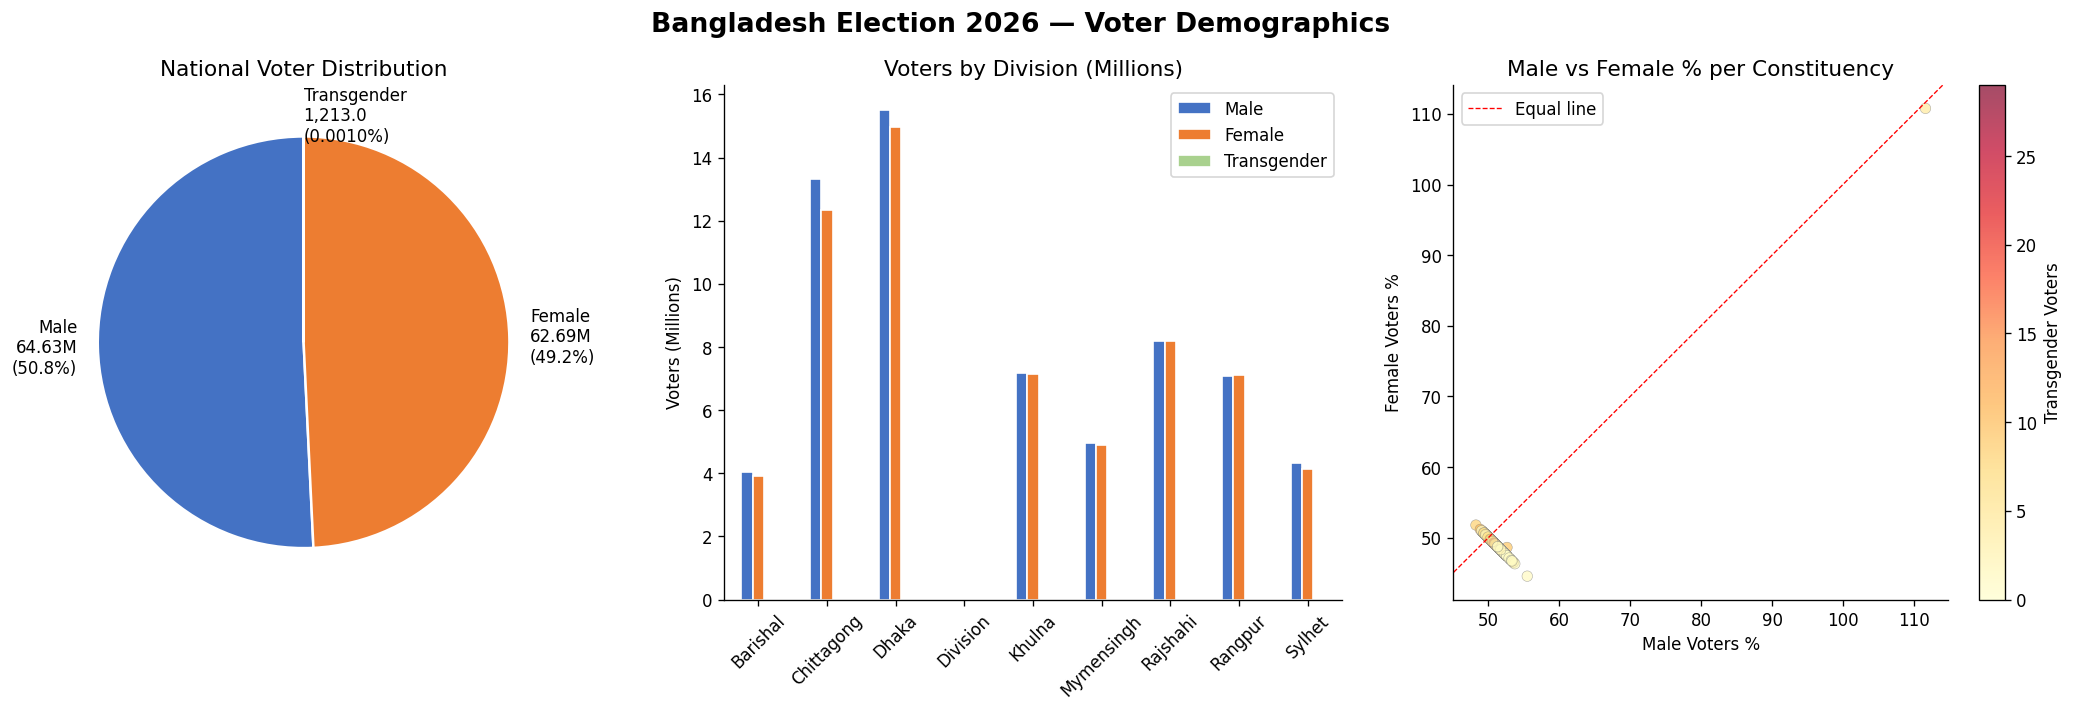


Voter Gender Summary:
  Total Male Voters      : 64,631,180.0  (50.76%)
  Total Female Voters    : 62,689,297.0  (49.24%)
  Total Transgender      :      1,213.0  (0.0010%)


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Bangladesh Election 2026 — Voter Demographics", fontsize=16, fontweight='bold')

# --- 5A. National aggregate pie ---------------
total_male  = df['Male_Voters'].sum()
total_fem   = df['Female_Voters'].sum()
total_trans = df['Transgender_Voters'].sum()
sizes       = [total_male, total_fem, total_trans]
labels      = [
    f"Male\n{total_male/1e6:.2f}M\n({total_male/(total_male+total_fem+total_trans)*100:.1f}%)",
    f"Female\n{total_fem/1e6:.2f}M\n({total_fem/(total_male+total_fem+total_trans)*100:.1f}%)",
    f"Transgender\n{total_trans:,}\n({total_trans/(total_male+total_fem+total_trans)*100:.4f}%)"
]
colors = ['#4472C4', '#ED7D31', '#A9D18E']
axes[0].pie(sizes, labels=labels, colors=colors, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title("National Voter Distribution", fontsize=13)

# --- 5B. Division-level grouped bar -----------
div_g = df.groupby('Division')[['Male_Voters','Female_Voters','Transgender_Voters']].sum()
div_g = div_g / 1e6   # millions
div_g.plot(kind='bar', ax=axes[1],
           color=['#4472C4','#ED7D31','#A9D18E'], edgecolor='white')
axes[1].set_title("Voters by Division (Millions)", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("Voters (Millions)")
axes[1].legend(['Male','Female','Transgender'], loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

# --- 5C. Male vs Female scatter by constituency
sc = axes[2].scatter(df['Male_Pct'], df['Female_Pct'],
                     c=df['Transgender_Voters'], cmap='YlOrRd',
                     alpha=0.7, edgecolors='grey', linewidth=0.3, s=40)
plt.colorbar(sc, ax=axes[2], label='Transgender Voters')
axes[2].set_xlabel("Male Voters %")
axes[2].set_ylabel("Female Voters %")
axes[2].set_title("Male vs Female % per Constituency", fontsize=13)
axes[2].axline((50, 50), slope=1, color='red', linestyle='--', linewidth=0.8, label='Equal line')
axes[2].legend()

plt.tight_layout()
plt.savefig('voter_demographics.png', bbox_inches='tight')
plt.show()

# Summary stats
print("\nVoter Gender Summary:")
print(f"  Total Male Voters      : {total_male:>12,}  ({total_male/(total_male+total_fem+total_trans)*100:.2f}%)")
print(f"  Total Female Voters    : {total_fem:>12,}  ({total_fem/(total_male+total_fem+total_trans)*100:.2f}%)")
print(f"  Total Transgender      : {total_trans:>12,}  ({total_trans/(total_male+total_fem+total_trans)*100:.4f}%)")




# ELECTION OVERVIEW — Party Results

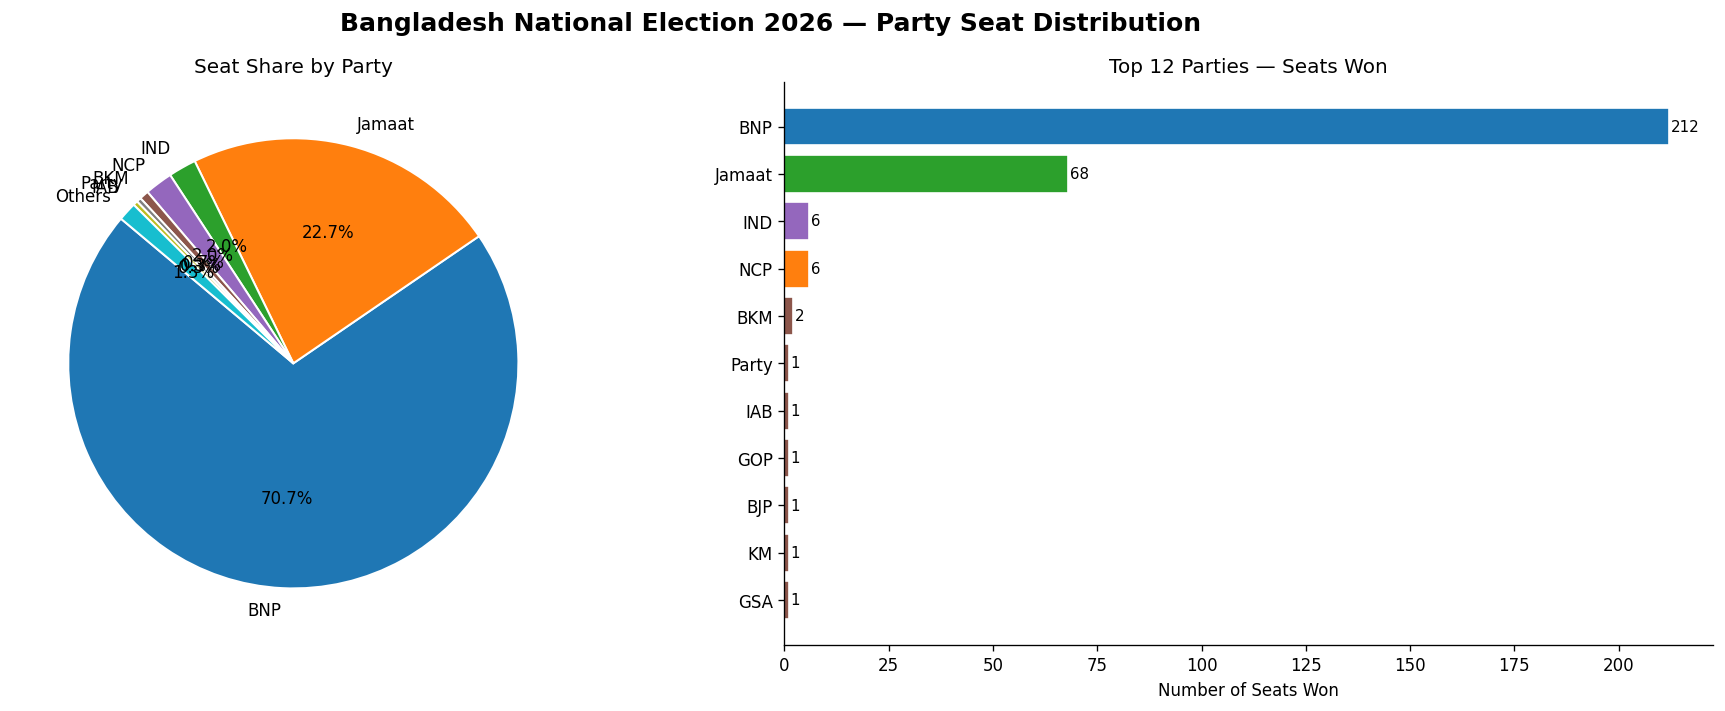


 Top 10 Parties:
 Party  Seats
   BNP    212
Jamaat     68
   IND      6
   NCP      6
   BKM      2
 Party      1
   IAB      1
   GOP      1
   BJP      1
    KM      1


In [ ]:

party_counts = df['Winner_Party'].value_counts().reset_index()
party_counts.columns = ['Party', 'Seats']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Bangladesh National Election 2026 — Party Seat Distribution",
             fontsize=15, fontweight='bold')

# Pie chart (top 8 + Others)
top_n = 7
top    = party_counts.head(top_n)
others = pd.DataFrame({'Party': ['Others'], 'Seats': [party_counts.iloc[top_n:]['Seats'].sum()]})
pie_df = pd.concat([top, others], ignore_index=True)

cmap = plt.cm.get_cmap('tab10', len(pie_df))
pie_colors = [cmap(i) for i in range(len(pie_df))]
axes[0].pie(pie_df['Seats'], labels=pie_df['Party'], colors=pie_colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.2})
axes[0].set_title("Seat Share by Party")

# Bar chart
colors_bar = [PALETTE.get(p, '#8c564b') for p in party_counts.head(12)['Party']]
axes[1].barh(party_counts.head(12)['Party'][::-1],
             party_counts.head(12)['Seats'][::-1],
             color=colors_bar[::-1], edgecolor='white')
axes[1].set_xlabel("Number of Seats Won")
axes[1].set_title("Top 12 Parties — Seats Won")
for i, (v, p) in enumerate(zip(party_counts.head(12)['Seats'][::-1],
                                party_counts.head(12)['Party'][::-1])):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('party_seat_distribution.png', bbox_inches='tight')
plt.show()

print("\n Top 10 Parties:")
print(party_counts.head(10).to_string(index=False))


#  GONOVOTE ANALYSIS

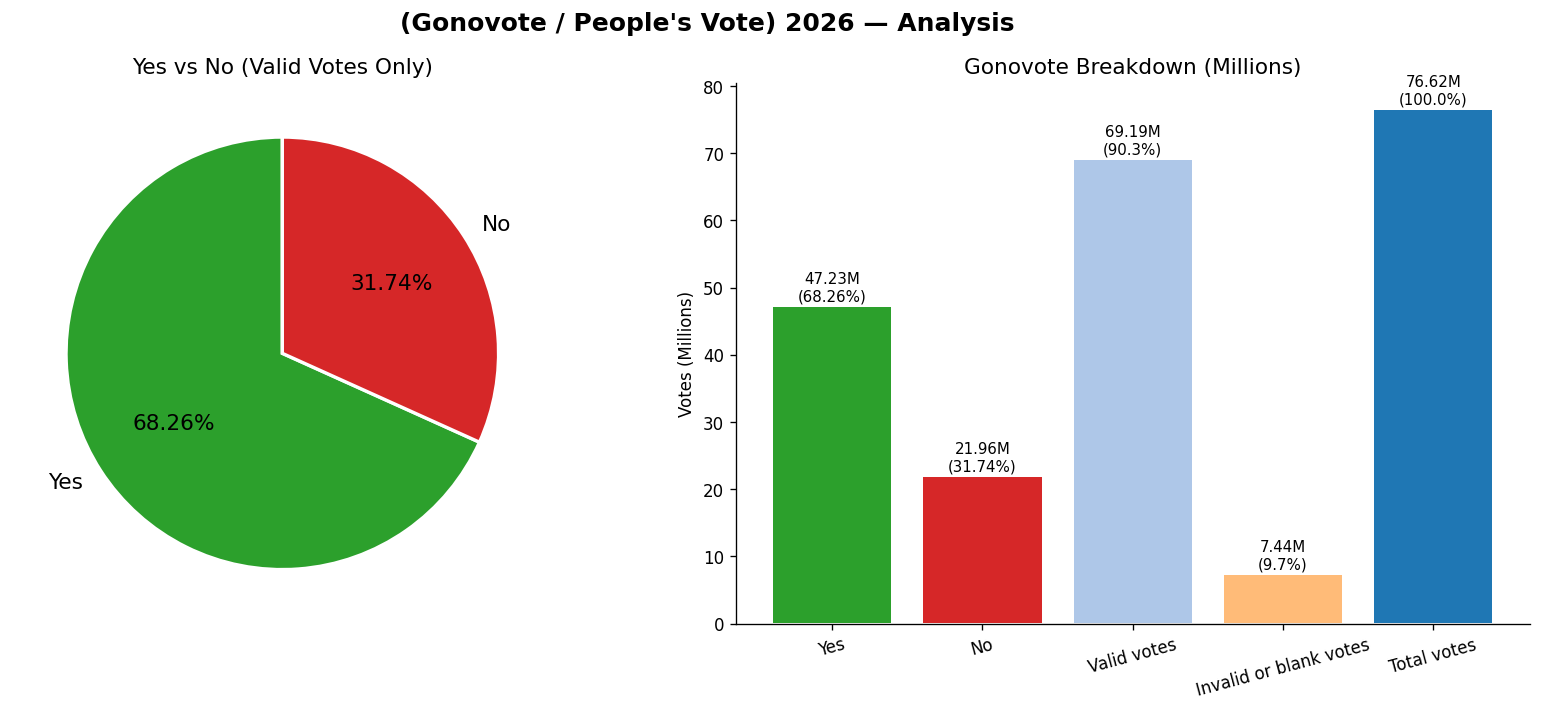


Gonovote Key Statistics:
  Total Votes Cast   :   76,621,407
  Valid Votes        :   69,186,211  (90.30%)
  Invalid / Blank    :    7,435,196  (9.70%)
  YES Votes          :   47,225,980  (68.26% of valid)
  NO  Votes          :   21,960,231  (31.74% of valid)


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("(Gonovote / People's Vote) 2026 — Analysis", fontsize=15, fontweight='bold')

# Pie: Yes vs No
yes_no = gv[gv['Choice'].isin(['Yes','No'])]
axes[0].pie(yes_no['Votes'], labels=yes_no['Choice'],
            autopct='%1.2f%%', colors=['#2ca02c','#d62728'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':13})
axes[0].set_title("Yes vs No (Valid Votes Only)", fontsize=13)

# Bar: Full breakdown
full = gv.iloc[:5].copy()
bar_colors = ['#2ca02c','#d62728','#aec7e8','#ffbb78','#1f77b4']
bars = axes[1].bar(full['Choice'], full['Votes']/1e6, color=bar_colors, edgecolor='white', linewidth=1.2)
axes[1].set_ylabel("Votes (Millions)")
axes[1].set_title("Gonovote Breakdown (Millions)", fontsize=13)
axes[1].tick_params(axis='x', rotation=15)
for bar, row in zip(bars, full.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{row.Votes/1e6:.2f}M\n({row.Percentage}%)",
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('gonovote_analysis.png', bbox_inches='tight')
plt.show()

print("\nGonovote Key Statistics:")
total_votes = gv[gv['Choice']=='Total votes']['Votes'].values[0]
valid_votes  = gv[gv['Choice']=='Valid votes']['Votes'].values[0]
yes_votes    = gv[gv['Choice']=='Yes']['Votes'].values[0]
no_votes     = gv[gv['Choice']=='No']['Votes'].values[0]
invalid_v    = gv[gv['Choice']=='Invalid or blank votes']['Votes'].values[0]
print(f"  Total Votes Cast   : {total_votes:>12,}")
print(f"  Valid Votes        : {valid_votes:>12,}  ({valid_votes/total_votes*100:.2f}%)")
print(f"  Invalid / Blank    : {invalid_v:>12,}  ({invalid_v/total_votes*100:.2f}%)")
print(f"  YES Votes          : {yes_votes:>12,}  ({yes_votes/valid_votes*100:.2f}% of valid)")
print(f"  NO  Votes          : {no_votes:>12,}  ({no_votes/valid_votes*100:.2f}% of valid)")



#  GEOGRAPHIC VISUALIZATION (Folium Map)

In [ ]:

# Division-level summary
div_summary = df.groupby('Division').agg(
    Total_Seats=('Constituency_No','count'),
    BNP_Seats=('Winner_Party', lambda x: (x=='BNP').sum()),
    Jamaat_Seats=('Winner_Party', lambda x: (x=='Jamaat').sum()),
    Avg_Turnout=('Voter_Turnout_Pct','mean'),
    Avg_Literacy=('Literacy_Rate','mean'),
    Avg_Poverty=('Poverty_Rate','mean'),
).reset_index()

bd_map = folium.Map(location=[23.68, 90.35], zoom_start=7, tiles='CartoDB positron')

# Color mapping for leading party
def lead_color(row):
    if row['BNP_Seats'] >= row['Jamaat_Seats']:
        return '#1f77b4'   # BNP blue
    return '#2ca02c'       # Jamaat green

for _, row in div_summary.iterrows():
    lat, lon = BD_DIVISIONS.get(row['Division'], (23.68, 90.35))
    color = lead_color(row)
    popup_html = f"""
    <div style='font-family:Arial;min-width:200px'>
      <b style='font-size:14px'>{row['Division']} Division</b><br>
      <hr style='margin:4px 0'>
      Total Seats: <b>{int(row['Total_Seats'])}</b><br>
      BNP Seats: <b style='color:#1f77b4'>{int(row['BNP_Seats'])}</b><br>
      Jamaat Seats: <b style='color:#2ca02c'>{int(row['Jamaat_Seats'])}</b><br>
      Avg Turnout: <b>{row['Avg_Turnout']:.1f}%</b><br>
      Avg Literacy: <b>{row['Avg_Literacy']:.1f}%</b><br>
      Avg Poverty: <b>{row['Avg_Poverty']:.1f}%</b>
    </div>
    """
    folium.CircleMarker(
        location=[lat, lon],
        radius=max(row['Total_Seats']/2, 10),
        color=color, fill=True, fill_color=color, fill_opacity=0.6,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{row['Division']}: {int(row['BNP_Seats'])} BNP | {int(row['Jamaat_Seats'])} Jamaat"
    ).add_to(bd_map)

# Constituency-level markers
mc = MarkerCluster().add_to(bd_map)
for _, row in df.iterrows():
    lat = row['Div_Lat'] + np.random.uniform(-0.3, 0.3)
    lon = row['Div_Lon'] + np.random.uniform(-0.3, 0.3)
    color = PALETTE.get(row['Winner_Party'], 'gray')

    # Handle potential NaN values for display
    winner_votes_display = f"{int(row['Winner_Votes']):,}" if pd.notna(row['Winner_Votes']) else "N/A"
    margin_display = f"{int(row['Margin']):,}" if pd.notna(row['Margin']) else "N/A"
    turnout_display = f"{row['Voter_Turnout_Pct']:.1f}%" if pd.notna(row['Voter_Turnout_Pct']) else "N/A"
    literacy_display = f"{row['Literacy_Rate']:.1f}%" if pd.notna(row['Literacy_Rate']) else "N/A"
    poverty_display = f"{row['Poverty_Rate']:.1f}%" if pd.notna(row['Poverty_Rate']) else "N/A"

    folium.CircleMarker(
        location=[lat, lon], radius=4,
        color=color, fill=True, fill_color=color, fill_opacity=0.8,
        tooltip=(f"{row['Constituency_Name']} | {row['Winner_Party']} | "
                 f"Turnout: {turnout_display}"),
        popup=folium.Popup(
            f"<b>{row['Constituency_Name']}</b><br>"
            f"Winner: {row['Winner_Candidate']} ({row['Winner_Party']})<br>"
            f"Votes: {winner_votes_display} | Margin: {margin_display}<br>"
            f"Turnout: {turnout_display} | "
            f"Literacy: {literacy_display} | Poverty: {poverty_display}",
            max_width=300)
    ).add_to(mc)

# Legend
legend_html = """
<div style='position:fixed;bottom:30px;left:30px;background:white;
            padding:10px;border-radius:8px;border:1px solid #ccc;
            font-family:Arial;font-size:12px;z-index:9999'>
  <b>Winner Party</b><br>
  <span style='color:#1f77b4'>●</span> BNP<br>
  <span style='color:#2ca02c'>●</span> Jamaat<br>
  <span style='color:#ff7f0e'>●</span> NCP<br>
  <span style='color:#9467bd'>●</span> Independent<br>
  <span style='color:#8c564b'>●</span> Other
</div>
"""
bd_map.get_root().html.add_child(folium.Element(legend_html))
bd_map.save('bangladesh_election_map.html')
print("Interactive map saved → bangladesh_election_map.html")
bd_map

Interactive map saved → bangladesh_election_map.html


#  CHARTS & GRAPHS — Voter Turnout

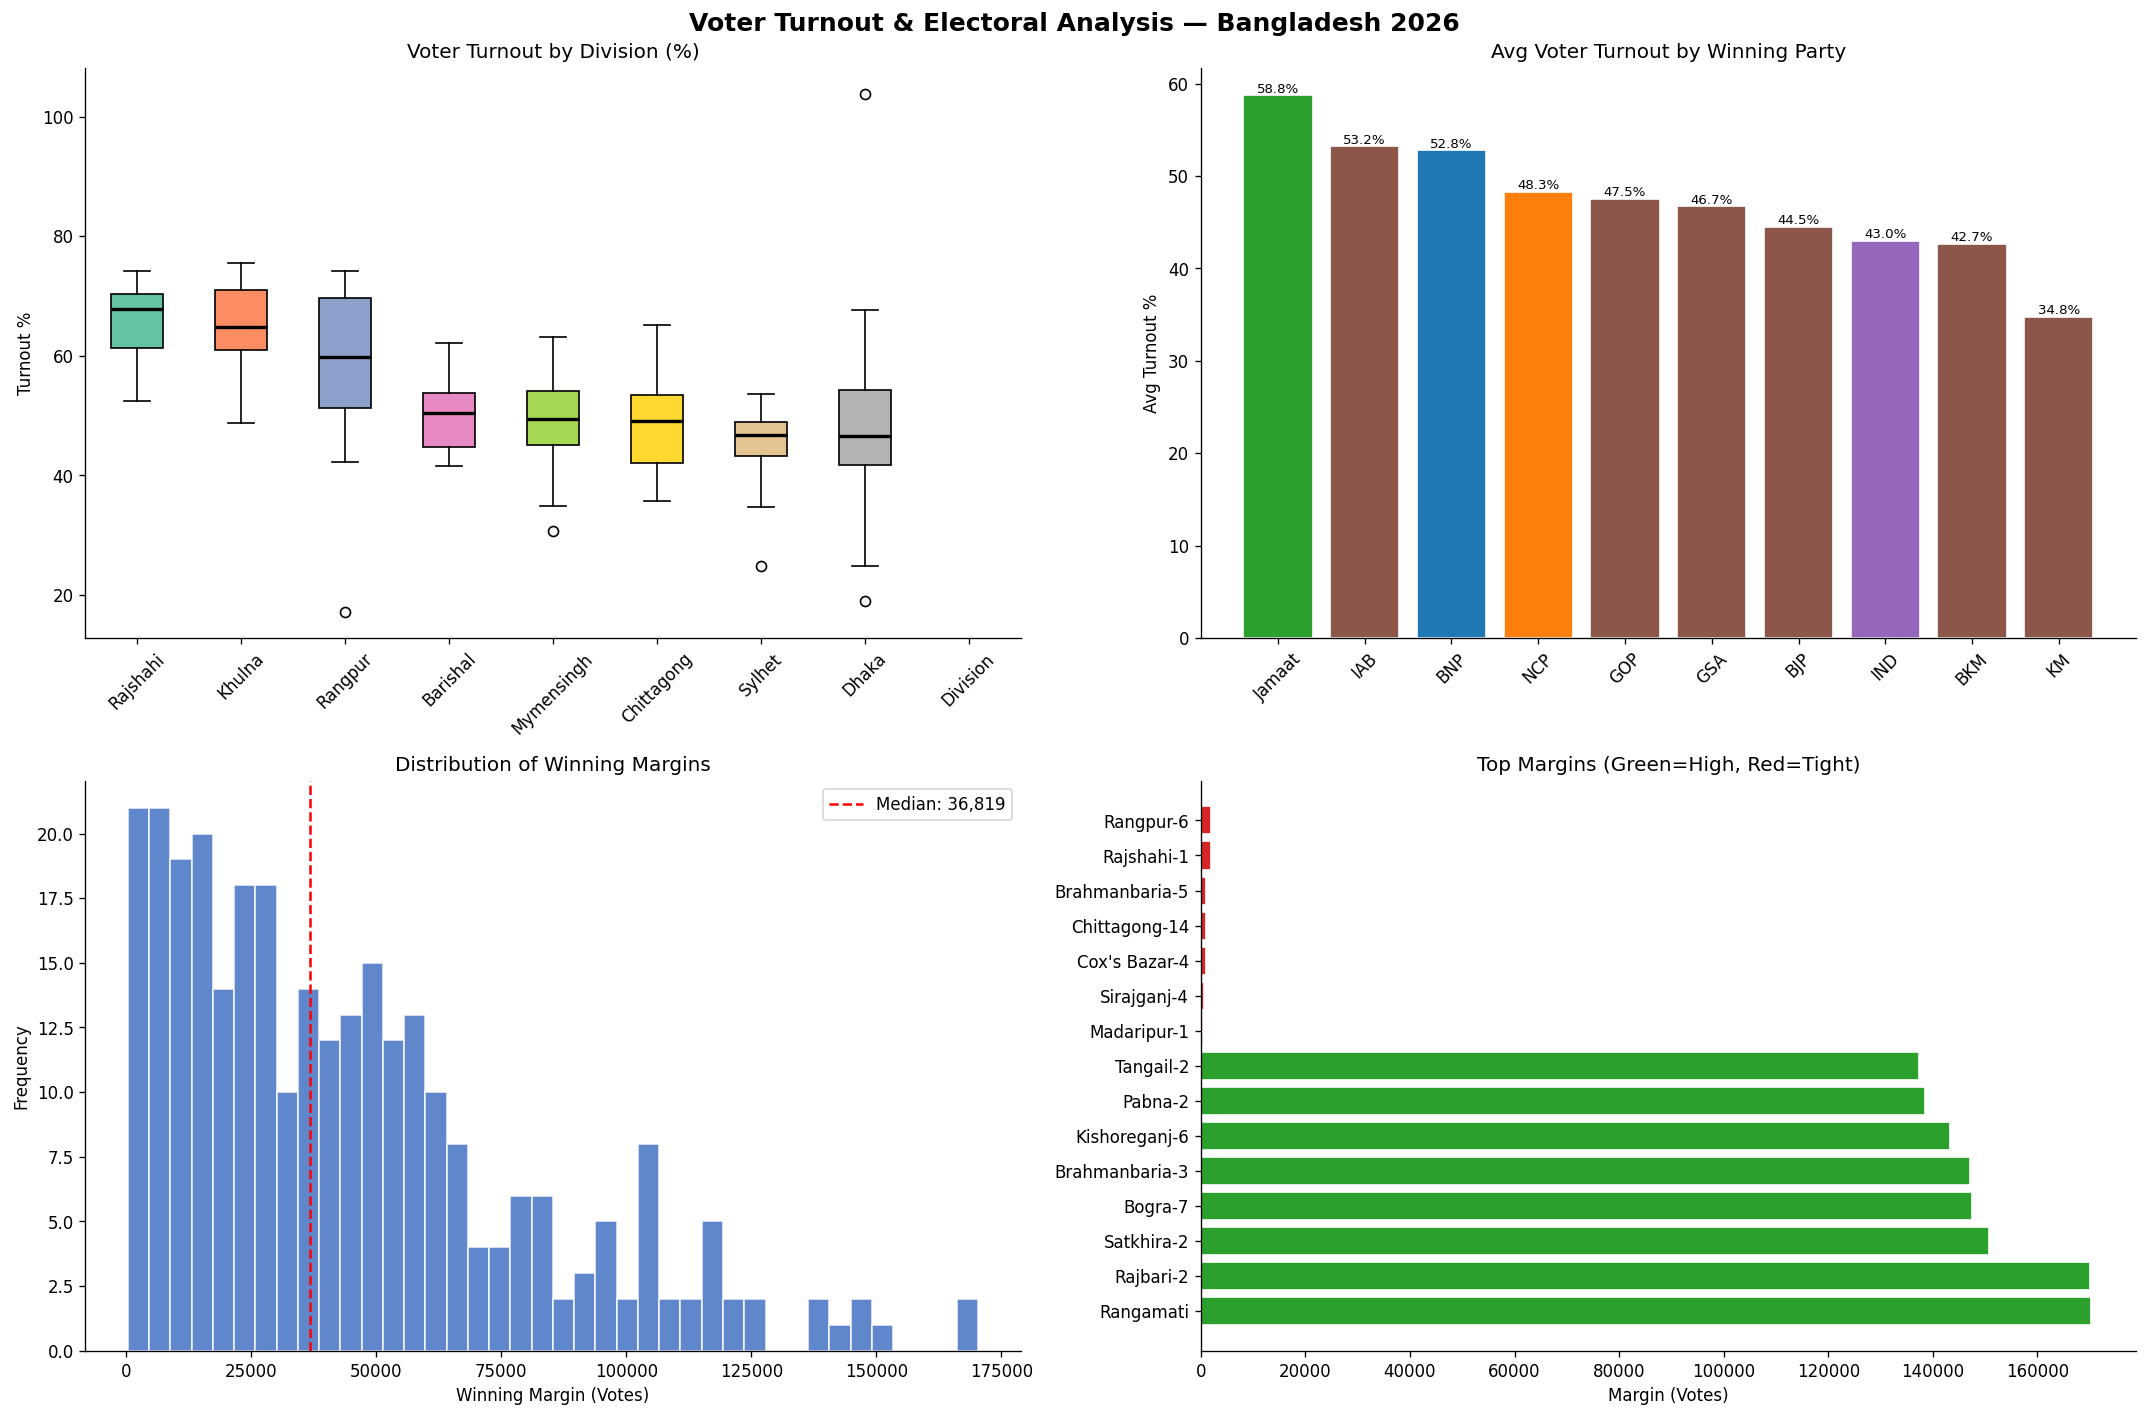

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Voter Turnout & Electoral Analysis — Bangladesh 2026",
             fontsize=15, fontweight='bold')

# 9A. Turnout by Division (box plot)
div_order = df.groupby('Division')['Voter_Turnout_Pct'].median().sort_values(ascending=False).index
df_plot = df[df['Division'].isin(div_order)]
bp_data = [df_plot[df_plot['Division']==d]['Voter_Turnout_Pct'].dropna().values
           for d in div_order]
bp = axes[0,0].boxplot(bp_data, labels=div_order, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
colors_div = plt.cm.Set2(np.linspace(0, 1, len(div_order)))
for patch, color in zip(bp['boxes'], colors_div):
    patch.set_facecolor(color)
axes[0,0].set_title("Voter Turnout by Division (%)")
axes[0,0].set_ylabel("Turnout %")
axes[0,0].tick_params(axis='x', rotation=45)

# 9B. Turnout by Winning Party
party_turnout = df.groupby('Winner_Party')['Voter_Turnout_Pct'].mean().sort_values(ascending=False).head(10)
colors_pt = [PALETTE.get(p, '#8c564b') for p in party_turnout.index]
axes[0,1].bar(party_turnout.index, party_turnout.values, color=colors_pt, edgecolor='white')
axes[0,1].set_title("Avg Voter Turnout by Winning Party")
axes[0,1].set_ylabel("Avg Turnout %")
axes[0,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(party_turnout.values):
    axes[0,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

# 9C. Winning Margin Distribution
axes[1,0].hist(df['Margin'].dropna(), bins=40, color='#4472C4', edgecolor='white', alpha=0.85)
axes[1,0].axvline(df['Margin'].median(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Median: {df['Margin'].median():,.0f}")
axes[1,0].set_title("Distribution of Winning Margins")
axes[1,0].set_xlabel("Winning Margin (Votes)")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend()

# 9D. Top 15 — Highest & Lowest Margins
top15_high = df.nlargest(8, 'Margin')[['Constituency_Name','Winner_Party','Margin']]
top15_low  = df.nsmallest(7, 'Margin')[['Constituency_Name','Winner_Party','Margin']]
combined   = pd.concat([top15_high, top15_low]).reset_index(drop=True)
bar_colors_c = ['#2ca02c' if v > 50000 else '#d62728' for v in combined['Margin']]
axes[1,1].barh(combined['Constituency_Name'], combined['Margin'],
               color=bar_colors_c, edgecolor='white')
axes[1,1].set_title("Top Margins (Green=High, Red=Tight)")
axes[1,1].set_xlabel("Margin (Votes)")
axes[1,1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('voter_turnout_charts.png', bbox_inches='tight')
plt.show()

# CORRELATION ANALYSIS (Pearson & Spearman)

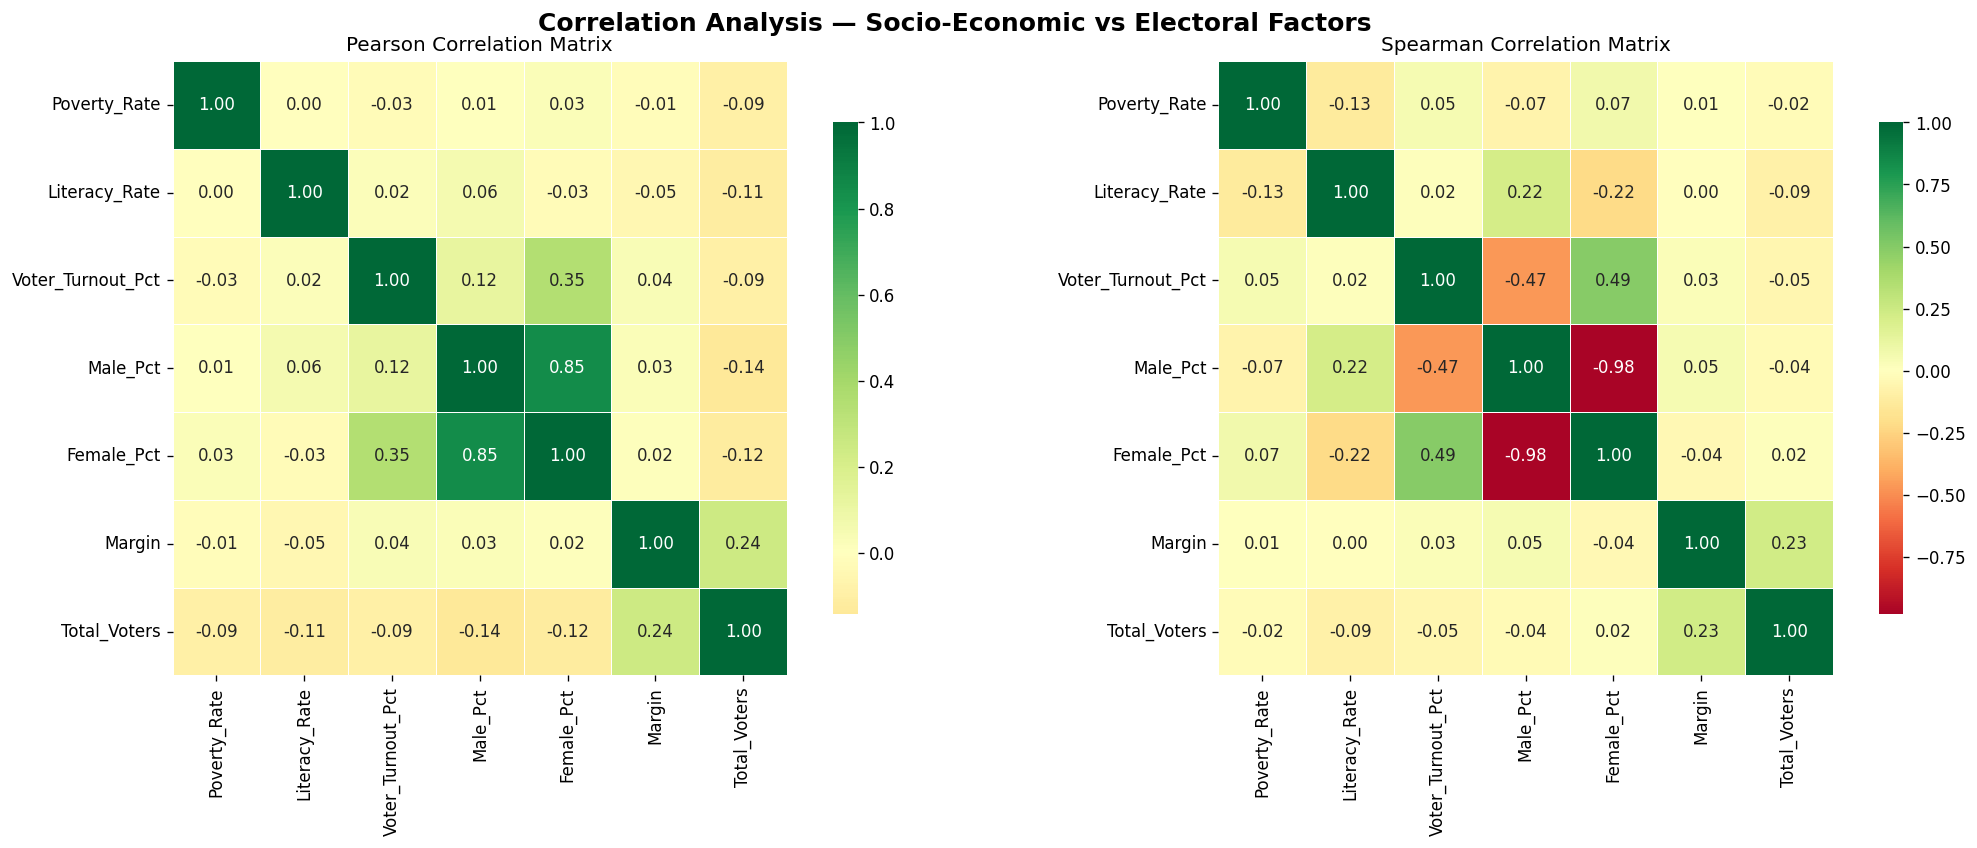


PySpark (MLlib) Pearson Correlation — Literacy Rate vs Voter Turnout:
  Literacy  ↔ Voter Turnout  (Pearson)  : r = 0.0198
  Poverty   ↔ Voter Turnout  (Pearson)  : r = -0.0262
  Literacy  ↔ Voter Turnout  (Spearman) : r = 0.0156
  Poverty   ↔ Voter Turnout  (Spearman) : r = 0.0509


In [ ]:
# --- Pandas correlations ----------------------
corr_features = ['Poverty_Rate','Literacy_Rate','Voter_Turnout_Pct',
                  'Male_Pct','Female_Pct','Margin','Total_Voters']
corr_df = df[corr_features].dropna()

pearson_matrix  = corr_df.corr(method='pearson')
spearman_matrix = corr_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Correlation Analysis — Socio-Economic vs Electoral Factors",
             fontsize=15, fontweight='bold')

sns.heatmap(pearson_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], square=True, linewidths=0.5,
            cbar_kws={'shrink':0.8})
axes[0].set_title("Pearson Correlation Matrix")

sns.heatmap(spearman_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1], square=True, linewidths=0.5,
            cbar_kws={'shrink':0.8})
axes[1].set_title("Spearman Correlation Matrix")

plt.tight_layout()
plt.savefig('correlation_heatmaps.png', bbox_inches='tight')
plt.show()

# --- PySpark Correlation (MLlib) ---------------
spark = SparkSession.builder.appName("BD_Election_2026").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

sdf = spark.createDataFrame(corr_df.fillna(0))
va  = VectorAssembler(inputCols=corr_features, outputCol='features')
sdf_vec = va.transform(sdf).select('features')

pcc_result = Correlation.corr(sdf_vec, 'features', 'pearson')
scc_result = Correlation.corr(sdf_vec, 'features', 'spearman')

pcc_arr = np.array(pcc_result.collect()[0][0].toArray())
scc_arr = np.array(scc_result.collect()[0][0].toArray())

print("\nPySpark (MLlib) Pearson Correlation — Literacy Rate vs Voter Turnout:")
lit_idx = corr_features.index('Literacy_Rate')
trn_idx = corr_features.index('Voter_Turnout_Pct')
pov_idx = corr_features.index('Poverty_Rate')

print(f"  Literacy  ↔ Voter Turnout  (Pearson)  : r = {pcc_arr[lit_idx, trn_idx]:.4f}")
print(f"  Poverty   ↔ Voter Turnout  (Pearson)  : r = {pcc_arr[pov_idx, trn_idx]:.4f}")
print(f"  Literacy  ↔ Voter Turnout  (Spearman) : r = {scc_arr[lit_idx, trn_idx]:.4f}")
print(f"  Poverty   ↔ Voter Turnout  (Spearman) : r = {scc_arr[pov_idx, trn_idx]:.4f}")

# GEOGRAPHIC CORRELATION — Division & Winning Party

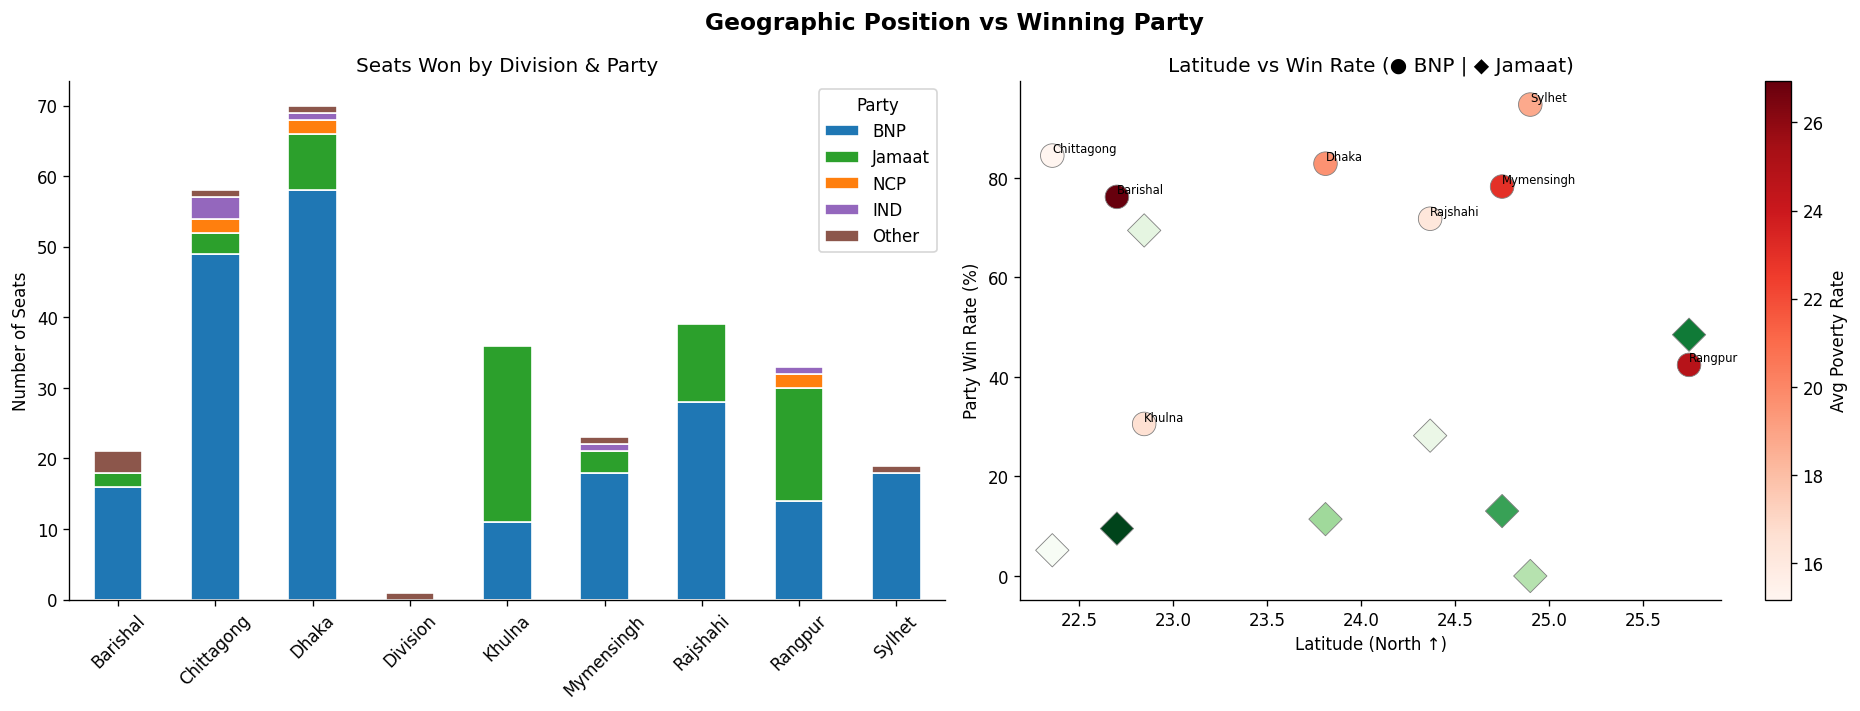


 Correlation — Geographic Position vs Winning Party:
  Latitude  ↔ BNP Win   (Pearson) : r = 0.0278
  Longitude ↔ BNP Win   (Pearson) : r = 0.1425


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Geographic Position vs Winning Party", fontsize=14, fontweight='bold')

# 11A. Party wins by division (stacked bar)
div_party = df.groupby(['Division','Winner_Party_Simple']).size().unstack(fill_value=0)
party_cols = [p for p in ['BNP','Jamaat','NCP','IND','Other'] if p in div_party.columns]
div_party[party_cols].plot(kind='bar', stacked=True, ax=axes[0],
                            color=[PALETTE[p] for p in party_cols], edgecolor='white')
axes[0].set_title("Seats Won by Division & Party")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Seats")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper right', title='Party')

# 11B. Latitude vs BNP win rate scatter
div_stats = df.groupby('Division').agg(
    BNP_Rate=('Winner_Party', lambda x: (x=='BNP').mean() * 100),
    Jamaat_Rate=('Winner_Party', lambda x: (x=='Jamaat').mean() * 100),
    Avg_Lat=('Div_Lat', 'mean'),
    Avg_Lon=('Div_Lon', 'mean'),
    Avg_Poverty=('Poverty_Rate', 'mean'),
).reset_index()

sc1 = axes[1].scatter(div_stats['Avg_Lat'], div_stats['BNP_Rate'],
                       c=div_stats['Avg_Poverty'], cmap='Reds',
                       s=200, edgecolors='grey', linewidth=0.5, zorder=3)
axes[1].scatter(div_stats['Avg_Lat'], div_stats['Jamaat_Rate'],
                c=div_stats['Avg_Poverty'], cmap='Greens',
                s=200, marker='D', edgecolors='grey', linewidth=0.5, zorder=3)
for _, row in div_stats.iterrows():
    axes[1].annotate(row['Division'], (row['Avg_Lat'], row['BNP_Rate']),
                     fontsize=7, ha='left', va='bottom')
plt.colorbar(sc1, ax=axes[1], label='Avg Poverty Rate')
axes[1].set_xlabel("Latitude (North ↑)")
axes[1].set_ylabel("Party Win Rate (%)")
axes[1].set_title("Latitude vs Win Rate (● BNP | ◆ Jamaat)")

plt.tight_layout()
plt.savefig('geographic_correlation.png', bbox_inches='tight')
plt.show()

# Numerical correlation
print("\n Correlation — Geographic Position vs Winning Party:")
df['BNP_Win'] = (df['Winner_Party'] == 'BNP').astype(int)
print(f"  Latitude  ↔ BNP Win   (Pearson) : r = {df['Div_Lat'].corr(df['BNP_Win']):.4f}")
print(f"  Longitude ↔ BNP Win   (Pearson) : r = {df['Div_Lon'].corr(df['BNP_Win']):.4f}")

#  LITERACY RATE vs WINNING PARTY

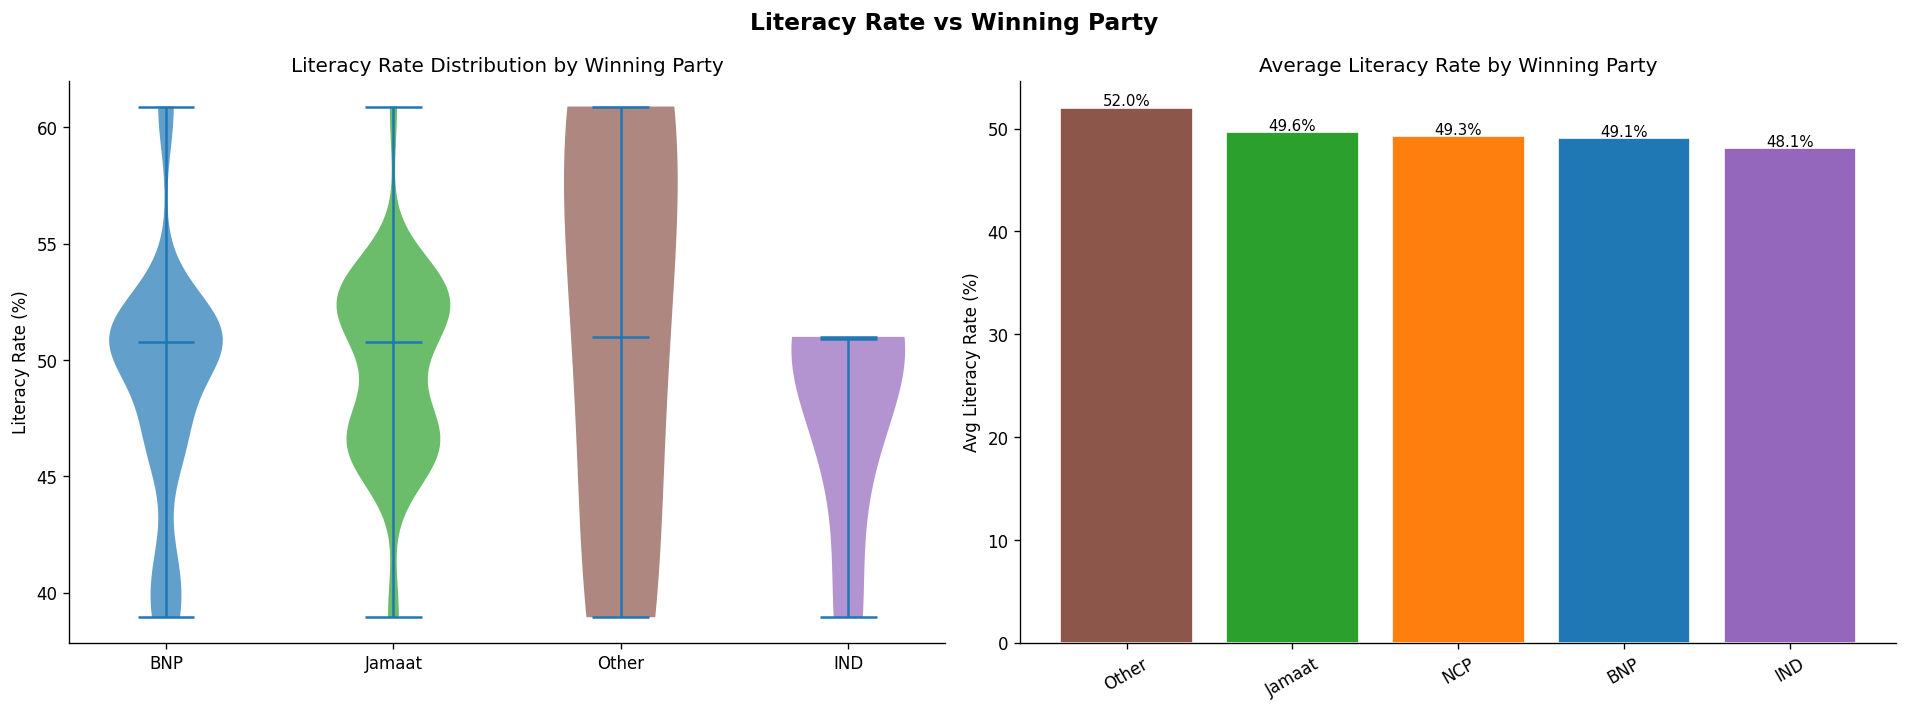


 Point-Biserial Correlation — Literacy Rate & Party Win:
  Literacy ↔ BNP Win    : r = -0.0556  (p = 0.3370)
  Literacy ↔ Jamaat Win : r = 0.0408  (p = 0.4815)


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Literacy Rate vs Winning Party", fontsize=14, fontweight='bold')

# 12A. Literacy rate distribution per party (violin)
top_parties = df['Winner_Party_Simple'].value_counts().head(4).index
df_top = df[df['Winner_Party_Simple'].isin(top_parties)]
party_literacy = [df_top[df_top['Winner_Party_Simple']==p]['Literacy_Rate'].dropna().values
                  for p in top_parties]
vp = axes[0].violinplot(party_literacy, positions=range(len(top_parties)),
                         showmedians=True, showmeans=False)
for i, (pc, p) in enumerate(zip(vp['bodies'], top_parties)):
    pc.set_facecolor(PALETTE.get(p, '#8c564b'))
    pc.set_alpha(0.7)
axes[0].set_xticks(range(len(top_parties)))
axes[0].set_xticklabels(top_parties)
axes[0].set_ylabel("Literacy Rate (%)")
axes[0].set_title("Literacy Rate Distribution by Winning Party")

# 12B. Avg literacy rate per party bar
lit_by_party = df.groupby('Winner_Party_Simple')['Literacy_Rate'].mean().sort_values(ascending=False)
bar_c = [PALETTE.get(p, '#8c564b') for p in lit_by_party.index]
axes[1].bar(lit_by_party.index, lit_by_party.values, color=bar_c, edgecolor='white')
axes[1].set_ylabel("Avg Literacy Rate (%)")
axes[1].set_title("Average Literacy Rate by Winning Party")
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(lit_by_party.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('literacy_vs_party.png', bbox_inches='tight')
plt.show()

# Point-biserial correlation
from scipy.stats import pointbiserialr
df['Jamaat_Win'] = (df['Winner_Party'] == 'Jamaat').astype(int)
bnp_r,   bnp_p   = pointbiserialr(df['Literacy_Rate'].fillna(df['Literacy_Rate'].mean()), df['BNP_Win'])
jam_r,   jam_p   = pointbiserialr(df['Literacy_Rate'].fillna(df['Literacy_Rate'].mean()), df['Jamaat_Win'])
print("\n Point-Biserial Correlation — Literacy Rate & Party Win:")
print(f"  Literacy ↔ BNP Win    : r = {bnp_r:.4f}  (p = {bnp_p:.4f})")
print(f"  Literacy ↔ Jamaat Win : r = {jam_r:.4f}  (p = {jam_p:.4f})")

# POVERTY vs WINNING PARTY

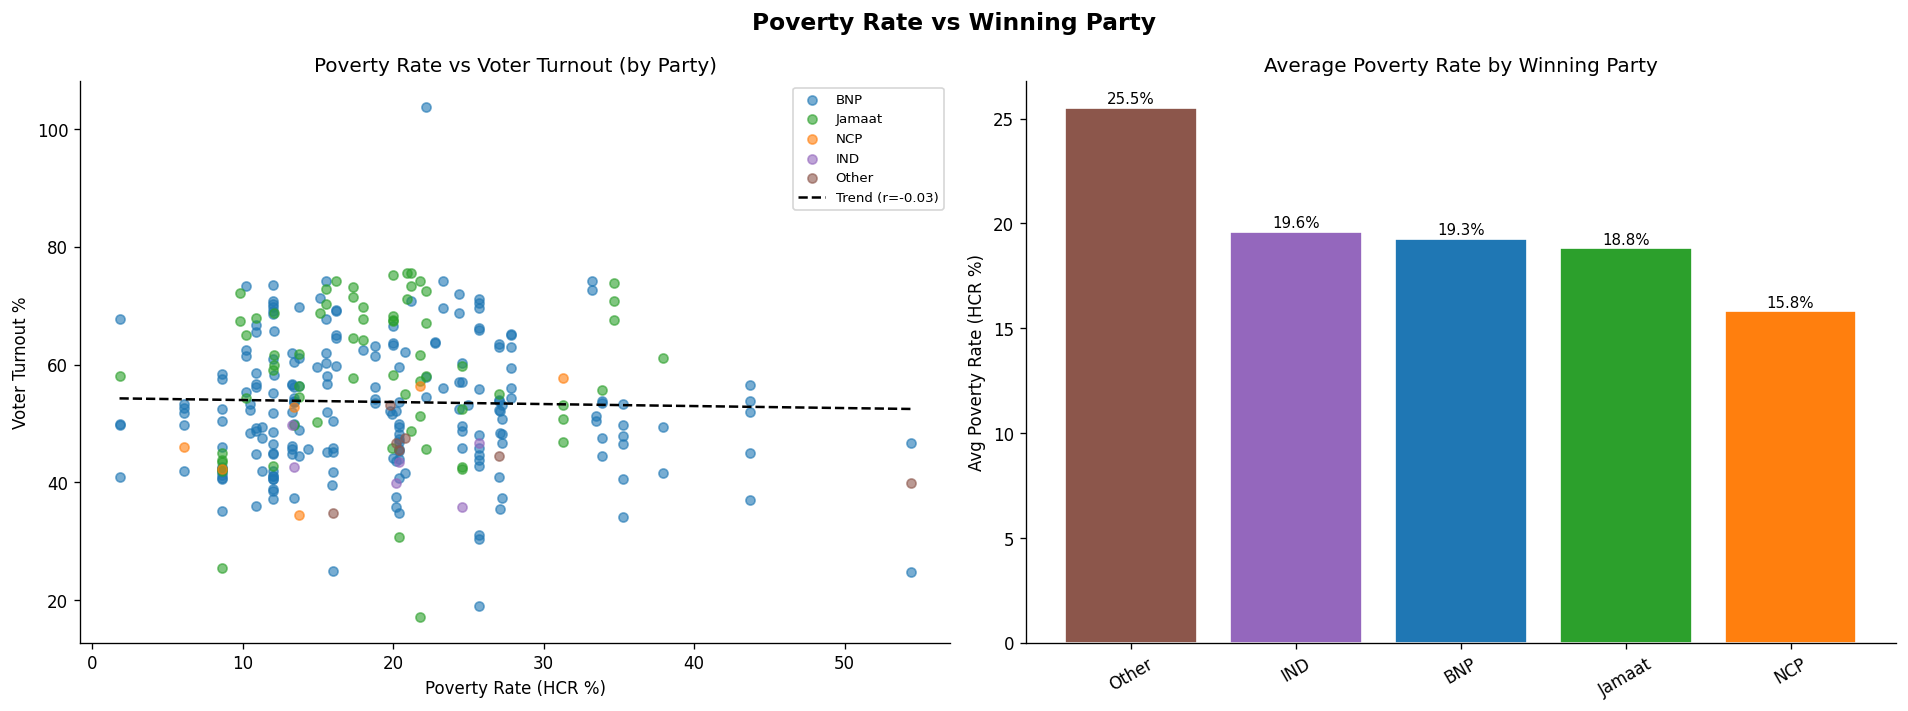


 Point-Biserial Correlation — Poverty Rate & Party Win:
  Poverty ↔ BNP Win    : r = 0.0029  (p = 0.9601)
  Poverty ↔ Jamaat Win : r = -0.0257  (p = 0.6579)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Poverty Rate vs Winning Party", fontsize=14, fontweight='bold')

# 13A. Scatter — poverty vs turnout, colored by party
for party in ['BNP','Jamaat','NCP','IND','Other']:
    sub = df[df['Winner_Party_Simple'] == party]
    axes[0].scatter(sub['Poverty_Rate'], sub['Voter_Turnout_Pct'],
                    label=party, color=PALETTE[party], alpha=0.6, s=30)
# Trend line
valid = df[['Poverty_Rate','Voter_Turnout_Pct']].dropna()
m, b = np.polyfit(valid['Poverty_Rate'], valid['Voter_Turnout_Pct'], 1)
xs = np.linspace(valid['Poverty_Rate'].min(), valid['Poverty_Rate'].max(), 100)
axes[0].plot(xs, m*xs + b, 'k--', linewidth=1.5, label=f'Trend (r={valid.corr().iloc[0,1]:.2f})')
axes[0].set_xlabel("Poverty Rate (HCR %)")
axes[0].set_ylabel("Voter Turnout %")
axes[0].set_title("Poverty Rate vs Voter Turnout (by Party)")
axes[0].legend(loc='upper right', fontsize=8)

# 13B. Avg poverty by winning party
pov_party = df.groupby('Winner_Party_Simple')['Poverty_Rate'].mean().sort_values(ascending=False)
bar_c2 = [PALETTE.get(p,'#8c564b') for p in pov_party.index]
axes[1].bar(pov_party.index, pov_party.values, color=bar_c2, edgecolor='white')
axes[1].set_ylabel("Avg Poverty Rate (HCR %)")
axes[1].set_title("Average Poverty Rate by Winning Party")
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(pov_party.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('poverty_vs_party.png', bbox_inches='tight')
plt.show()

pov_bnp_r, pov_bnp_p   = pointbiserialr(df['Poverty_Rate'].fillna(df['Poverty_Rate'].mean()), df['BNP_Win'])
pov_jam_r, pov_jam_p   = pointbiserialr(df['Poverty_Rate'].fillna(df['Poverty_Rate'].mean()), df['Jamaat_Win'])
print("\n Point-Biserial Correlation — Poverty Rate & Party Win:")
print(f"  Poverty ↔ BNP Win    : r = {pov_bnp_r:.4f}  (p = {pov_bnp_p:.4f})")
print(f"  Poverty ↔ Jamaat Win : r = {pov_jam_r:.4f}  (p = {pov_jam_p:.4f})")

#  K-MEANS CLUSTERING



 Cluster Profiles (K=3):
         Poverty_Rate  Literacy_Rate  Voter_Turnout_Pct  Male_Pct  Female_Pct    Margin
Cluster                                                                                
0               16.59          52.20              48.26     51.16       48.84  48621.72
1               22.17          45.97              59.33     50.34       49.66  40139.52
2               22.20          50.80             103.81    111.64      110.78  59955.00


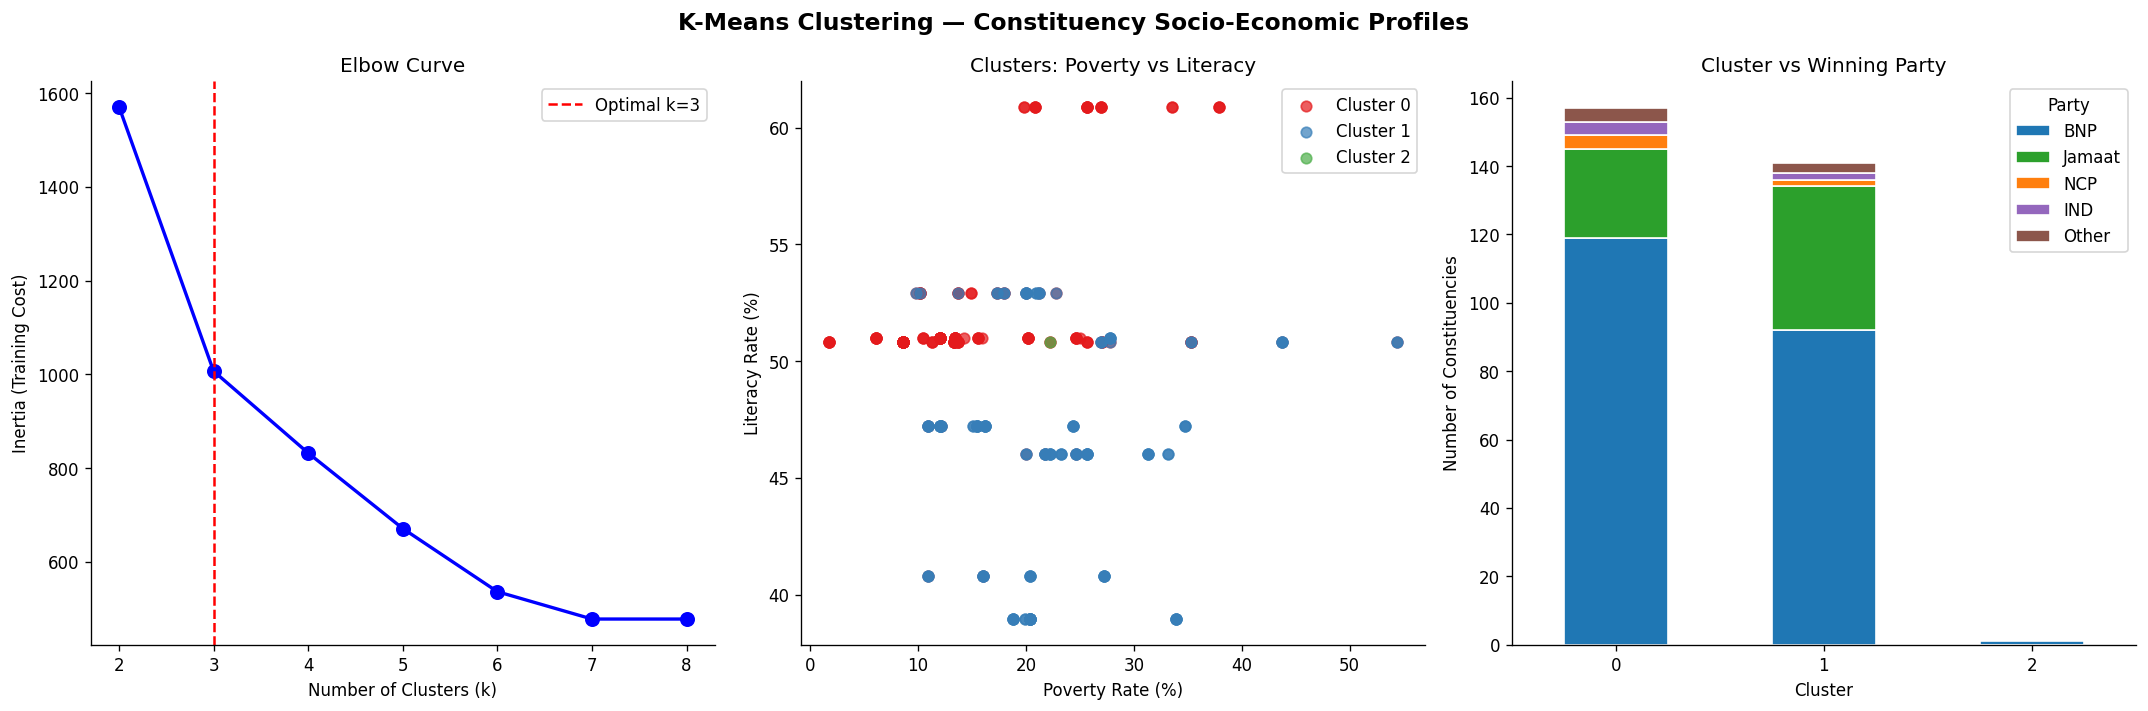

In [ ]:
clust_features = ['Poverty_Rate','Literacy_Rate','Voter_Turnout_Pct',
                   'Male_Pct','Female_Pct','Margin']
clust_df = df[clust_features + ['Division','Winner_Party_Simple']].dropna()
clust_sdf = spark.createDataFrame(clust_df[clust_features])
for c in clust_features:
    clust_sdf = clust_sdf.withColumn(c, col(c).cast(DoubleType()))

va_km   = VectorAssembler(inputCols=clust_features, outputCol='raw_features')
sc_km   = StandardScaler(inputCol='raw_features', outputCol='features', withStd=True, withMean=True)

inertias = []
K_range  = range(2, 9)
for k in K_range:
    km    = KMeans(featuresCol='features', k=k, seed=42)
    pipe  = Pipeline(stages=[va_km, sc_km, km])
    model = pipe.fit(clust_sdf)
    inertias.append(model.stages[-1].summary.trainingCost)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("K-Means Clustering — Constituency Socio-Economic Profiles",
             fontsize=14, fontweight='bold')

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Training Cost)")
axes[0].set_title("Elbow Curve")
axes[0].axvline(3, color='red', linestyle='--', label='Optimal k=3')
axes[0].legend()

# Fit with optimal k=3
km_opt  = KMeans(featuresCol='features', k=3, seed=42)
pipe_km = Pipeline(stages=[va_km, sc_km, km_opt])
km_fit  = pipe_km.fit(clust_sdf)
km_pred = km_fit.transform(clust_sdf)

clust_result = km_pred.select('prediction').toPandas()
clust_df     = clust_df.reset_index(drop=True)
clust_df['Cluster'] = clust_result['prediction']

# Cluster profiles
cluster_profile = clust_df.groupby('Cluster')[clust_features].mean().round(2)
print("\n Cluster Profiles (K=3):")
print(cluster_profile.to_string())

# Cluster scatter — Poverty vs Literacy, colored by cluster
colors_km = ['#e41a1c','#377eb8','#4daf4a']
for c in [0, 1, 2]:
    sub = clust_df[clust_df['Cluster'] == c]
    axes[1].scatter(sub['Poverty_Rate'], sub['Literacy_Rate'],
                    label=f'Cluster {c}', color=colors_km[c], alpha=0.7, s=40)
axes[1].set_xlabel("Poverty Rate (%)")
axes[1].set_ylabel("Literacy Rate (%)")
axes[1].set_title("Clusters: Poverty vs Literacy")
axes[1].legend()

# Cluster vs Party distribution
clu_party = clust_df.groupby(['Cluster','Winner_Party_Simple']).size().unstack(fill_value=0)
clu_cols  = [p for p in ['BNP','Jamaat','NCP','IND','Other'] if p in clu_party.columns]
clu_party[clu_cols].plot(kind='bar', stacked=True, ax=axes[2],
                          color=[PALETTE[p] for p in clu_cols], edgecolor='white')
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Number of Constituencies")
axes[2].set_title("Cluster vs Winning Party")
axes[2].legend(title='Party', loc='upper right')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('kmeans_clustering.png', bbox_inches='tight')
plt.show()